# Syntax controls for concatenated Pythia representations

Compare the true syntax norm fraction against five controls for concatenated representations (`avg_tokens=0`):
- syntax-shuffle control: batch-shuffled syntax centroids
- token-shuffle control: token-shuffled syntax centroids only
- syntax+token-shuffle control: both centroid shuffles together
- word-shuffled-input control: activations from word-shuffled input sentences, evaluated against the true centroids
- lexical-orthogonalized activations: remove each token's projection along its matched layer-0 token representation before measuring syntax overlap

Important: the token-shuffle controls act on the syntax centroids only. The sentence activations are left unchanged. The word-shuffled-input control instead changes the activations and keeps the true centroids fixed.

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

models = [
    'pythia6p9b_step0',
    'pythia6p9b_step512',
    'pythia6p9b_step4000',
    'pythia6p9b_step16000',
    'pythia6p9b_step64000',
    'pythia6p9b_step143000',
]
min_token_length = 3
n_samples = 2018
global_center_flag = 1
layer_reduce = 'mean'  # options: 'mean', 'max', 'fixed_layer'
fixed_layer_index = 0

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 15
plt.rcParams['figure.autolayout'] = True


def reduce_layers(values):

    reducers = {

        'mean': np.mean,

        'max': np.max,

        'fixed_layer': lambda arr: arr[fixed_layer_index],

    }

    if layer_reduce not in reducers:

        raise ValueError(f"Unsupported layer_reduce={layer_reduce!r}; expected one of {tuple(reducers)}")

    if layer_reduce == 'fixed_layer' and not 0 <= fixed_layer_index < len(values):

        raise IndexError(f"fixed_layer_index={fixed_layer_index} is out of bounds for {len(values)} layers")

    return float(reducers[layer_reduce](values))




def layer_reduce_label():

    if layer_reduce == 'fixed_layer':

        return f'layer {fixed_layer_index}'

    return f'{layer_reduce} across layers'



def load_concat_run(model, activation_match_var='matching'):
    root = (
        Path('/home/acevedo/syn-sem/pythia/results')
        / f'model_{model}'
        / 'avg_tokens_0'
        / f'min_token_length_{min_token_length}'
        / f'n_samples_{n_samples}'
        / 'norms'
        / f'global_center_flag_{global_center_flag}'
    )
    if activation_match_var != 'matching':
        root = root / f'activation_match_var_{activation_match_var}'
    path = root / 'norms.npz'
    if not path.exists():
        return None
    return np.load(path)


def load_lexical_orth_run(model, activation_match_var='matching'):
    root = (
        Path('/home/acevedo/syn-sem/pythia/results')
        / f'model_{model}'
        / 'avg_tokens_0'
        / f'min_token_length_{min_token_length}'
        / f'n_samples_{n_samples}'
        / 'norms_lexical_orth'
        / f'global_center_flag_{global_center_flag}'
    )
    if activation_match_var != 'matching':
        root = root / f'activation_match_var_{activation_match_var}'
    path = root / 'lexical_orth_norms.npz'
    if not path.exists():
        return None
    return np.load(path)


In [10]:
checkpoint_steps = []
true_means = []
syntax_shuffle_means = []
true_stds = []
token_shuffle_means = []
syntax_token_shuffle_means = []
word_shuffle_input_means = []
lexical_orth_means = []

for model in models:
    run_true = load_concat_run(model)
    run_word_shuffle = load_concat_run(model, activation_match_var='matching_wordshuffled')
    run_lexical_orth = load_lexical_orth_run(model)
    if run_true is None or run_word_shuffle is None or run_lexical_orth is None:
        print(f'skipping {model}: missing one of the norm files')
        continue
    needed_true = ['permuted_syn_means', 'shuffled_tokens_syn_means', 'combined_shuffle_syn_means']
    if any(key not in run_true.files for key in needed_true):
        print(f'skipping {model}: missing one of the centroid-side controls')
        continue
    if 'lexical_orth_syn_means' not in run_lexical_orth.files:
        print(f'skipping {model}: missing lexical control')
        continue

    checkpoint_steps.append(int(model.split('step')[-1]))
    true_means.append(reduce_layers(run_true['syn_means']))
    true_stds.append(reduce_layers(run_true['syn_stds']))
    syntax_shuffle_means.append(reduce_layers(run_true['permuted_syn_means']))
    token_shuffle_means.append(reduce_layers(run_true['shuffled_tokens_syn_means']))
    syntax_token_shuffle_means.append(reduce_layers(run_true['combined_shuffle_syn_means']))
    word_shuffle_input_means.append(reduce_layers(run_word_shuffle['syn_means']))
    lexical_orth_means.append(reduce_layers(run_lexical_orth['lexical_orth_syn_means']))

checkpoint_steps = np.array(checkpoint_steps)
true_means = np.array(true_means)
true_stds = np.array(true_stds)
syntax_shuffle_means = np.array(syntax_shuffle_means)
token_shuffle_means = np.array(token_shuffle_means)
syntax_token_shuffle_means = np.array(syntax_token_shuffle_means)
word_shuffle_input_means = np.array(word_shuffle_input_means)
lexical_orth_means = np.array(lexical_orth_means)




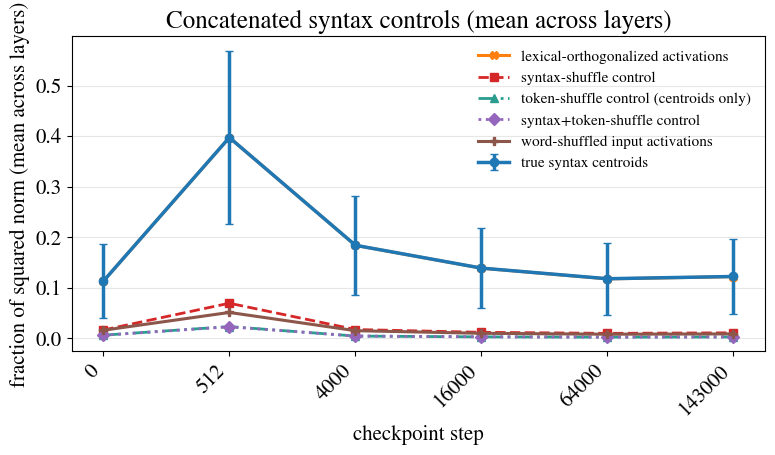

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8.0, 4.8))

plot_x = np.arange(len(checkpoint_steps))
ax.errorbar(plot_x, true_means, yerr=true_stds, marker='o', linewidth=2.5, color='#1f77b4', capsize=3, label='true syntax centroids')
ax.plot(plot_x, lexical_orth_means, marker='X', linewidth=2.2, color='#ff7f0e', label='lexical-orthogonalized activations')
ax.plot(plot_x, syntax_shuffle_means, marker='s', linewidth=2.0, linestyle='--', color='#d62728', label='syntax-shuffle control')
ax.plot(plot_x, token_shuffle_means, marker='^', linewidth=2.0, linestyle='-.', color='#2a9d8f', label='token-shuffle control (centroids only)')
ax.plot(plot_x, syntax_token_shuffle_means, marker='D', linewidth=2.0, linestyle=':', color='#9467bd', label='syntax+token-shuffle control')
ax.plot(plot_x, word_shuffle_input_means, marker='P', linewidth=2.2, color='#8c564b', label='word-shuffled input activations')
ax.set_xticks(plot_x)
ax.set_xticklabels(checkpoint_steps, rotation=45, ha='right')
ax.set_xlabel('checkpoint step')
ax.set_ylabel(f'fraction of squared norm ({layer_reduce_label()})')
ax.set_title(f'Concatenated syntax controls ({layer_reduce_label()})')
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, fontsize=11)

plt.show()
